# GLM-HMM Visualization — 5.50

Comprehensive visualization of the best-performing GLM-HMM model selected in `5.21`:
`no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv`

Figures:
1. **Model selection** — bits/trial vs K for all 5 groups
2. **GLM weight heatmaps** — pooled model weights per group
3. **State occupancy** — bar plot across groups with session dots
4. **State-specific psychometric curves** — by group and color condition
5. **Transition matrices** — mean across sessions per group
6. **Paired medication effect** — ON vs OFF occupancy within subjects
7. **Trial-level state posteriors** — example sessions per group
8. **Dwell time distributions** — per hidden state across groups

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import pickle
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import linear_sum_assignment
from scipy.special import expit
from scipy.stats import wilcoxon

warnings.filterwarnings('ignore')

from imports import *
from config import dir_config
from src.glm_hmm.cv_utils import bernoulli_null_loglik, pooled_bits_per_trial

plt.rcParams.update({'font.family': 'sans-serif', 'axes.grid': False})
DPI = 150

In [3]:
processed_dir  = Path(dir_config.data.processed)
glm_hmm_dir    = processed_dir / 'glm_hmm'

SELECTED_MODEL = 'no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv'
model_dir      = glm_hmm_dir / SELECTED_MODEL

fig_dir = model_dir / 'figures'
fig_dir.mkdir(exist_ok=True)

GROUPS       = ['asmHC', 'Tremor_OFF', 'Brady_OFF', 'Tremor_ON', 'Brady_ON']
GROUP_LABELS = {
    'asmHC':      'HC',
    'Tremor_OFF': 'Tremor OFF',
    'Brady_OFF':  'Brady OFF',
    'Tremor_ON':  'Tremor ON',
    'Brady_ON':   'Brady ON',
}
GROUP_COLORS = {
    'asmHC':      '#2166ac',
    'Tremor_OFF': '#d6604d',
    'Brady_OFF':  '#f4a582',
    'Tremor_ON':  '#b2182b',
    'Brady_ON':   '#fddbc7',
}
STATE_COLORS = ['#ff7f00', '#4daf4a', '#377eb8', '#e41a1c', '#984ea3']

# Medication subtype pairing for Fig 6
MED_PAIRS = [
    ('Tremor', 'Tremor_OFF', 'Tremor_ON'),
    ('Bradykinesia', 'Brady_OFF', 'Brady_ON'),
]

print(f'Model: {SELECTED_MODEL}')

Model: no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv


## Load data

In [4]:
def align_states(session_w, ref_w):
    """Hungarian-algorithm permutation to align session states to the pooled reference."""
    K = session_w.shape[0]
    cost = np.array([[np.sum((session_w[i] - ref_w[j]) ** 2)
                      for j in range(K)] for i in range(K)])
    _, col_ind = linear_sum_assignment(cost)
    inv = np.empty_like(col_ind)
    inv[col_ind] = np.arange(K)
    return inv


def load_group(group_name):
    """Load and align a group's finetuned bundle."""
    pkl = model_dir / f'{group_name}_final.pkl'
    if not pkl.exists():
        print(f'  Missing: {pkl}')
        return None
    bundle = pickle.load(open(pkl, 'rb'))
    config   = bundle['config']
    K        = bundle['best_k']
    pooled   = bundle['model']['pooled']
    ref_w    = -pooled.observations.params[:, 0, :]   # (K, M)

    weights, posteriors, occupancy, viterbi_seqs, session_ids = {}, {}, {}, {}, []

    for sid, model in bundle['model']['models'].items():
        df       = bundle['data'][sid]
        feats    = config['model_features']
        inputs   = df[feats].values.astype(np.float64)
        choices  = df['choices'].values.reshape(-1, 1).astype(int)
        mask     = df['mask'].values.reshape(-1, 1).astype(bool)
        valid    = mask[:, 0]

        sess_w   = -model.observations.params[:, 0, :]  # (K, M)
        perm     = align_states(sess_w, ref_w)

        weights[sid]  = sess_w[perm]
        post          = model.expected_states(choices, input=inputs, mask=mask)[0]  # (T, K)
        post_aligned  = post[:, perm]
        posteriors[sid]  = post_aligned
        occupancy[sid]   = post_aligned[valid].mean(0)   # (K,)
        vit              = np.argmax(post_aligned, axis=1)[valid]
        viterbi_seqs[sid] = perm[np.argmax(post[:, :], axis=1)][valid]  # aligned viterbi
        session_ids.append(sid)

    return {
        'config':     config,
        'best_k':     K,
        'ref_w':      ref_w,
        'pooled':     pooled,
        'models':     bundle['model']['models'],
        'weights':    weights,      # sid → (K, M)
        'posteriors': posteriors,   # sid → (T, K)
        'occupancy':  occupancy,    # sid → (K,)
        'viterbi':    viterbi_seqs, # sid → (T_valid,)
        'session_ids': session_ids,
        'raw':        bundle,
    }


def load_cv_bundle(group_name):
    pkl = model_dir / f'{group_name}.pkl'
    if not pkl.exists():
        return None
    return pickle.load(open(pkl, 'rb'))


group_data = {}
cv_bundles = {}
for g in GROUPS:
    data = load_group(g)
    if data is not None:
        group_data[g] = data
        print(f'{g:12s}  K={data["best_k"]}  n_sessions={len(data["session_ids"])}')
    cv_bundles[g] = load_cv_bundle(g)

asmHC         K=3  n_sessions=18
Tremor_OFF    K=2  n_sessions=11
Brady_OFF     K=1  n_sessions=10
Tremor_ON     K=3  n_sessions=11
Brady_ON      K=3  n_sessions=10


In [5]:
def despine(ax):
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def state_cols(K):
    return STATE_COLORS[:K]


def stacked_occ(gdata):
    """(S, K) array of per-session occupancy for a group."""
    return np.stack([gdata['occupancy'][sid] for sid in gdata['session_ids']])


def stacked_w(gdata):
    """(S, K, M) array of per-session weights."""
    return np.stack([gdata['weights'][sid] for sid in gdata['session_ids']])

## Figure 1 — Cross-Group Model Selection

Bits/trial vs K for all 5 groups. Circle marks the parsimonious best K per group.

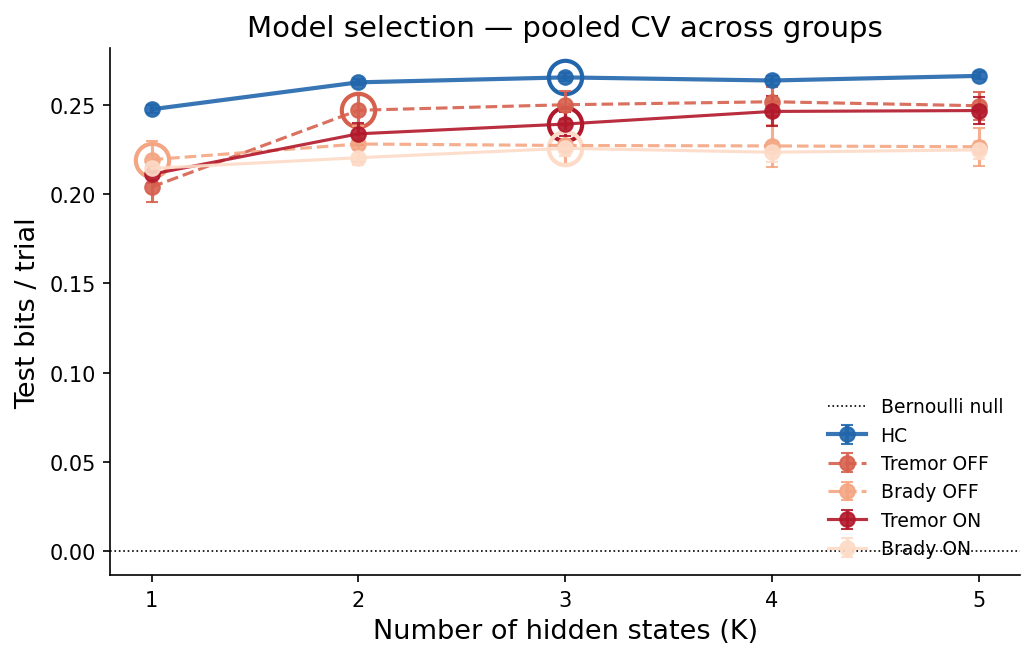

In [6]:
def parsimonious_k(states, mean_bits, sem_bits):
    best_idx   = int(np.argmax(mean_bits))
    cutoff     = mean_bits[best_idx] - sem_bits[best_idx]
    chosen_idx = next(i for i in range(best_idx + 1) if mean_bits[i] >= cutoff)
    return int(states[chosen_idx])


def pooled_bits(cv_bundle):
    gpc        = cv_bundle['group_pooled_cv']
    null_ll, n_valid = bernoulli_null_loglik(cv_bundle['data'])
    mean_bits, sem_bits = pooled_bits_per_trial(
        gpc['test_ll'], gpc['n_test_trials'], null_ll, n_valid)
    return np.asarray(gpc['state_range']), mean_bits, sem_bits


fig, ax = plt.subplots(figsize=(7, 4.5), dpi=DPI)

for g in GROUPS:
    if cv_bundles.get(g) is None:
        continue
    states, mean_b, sem_b = pooled_bits(cv_bundles[g])
    best_k = group_data[g]['best_k'] if g in group_data else parsimonious_k(states, mean_b, sem_b)
    ls = '-' if g in ('asmHC', 'Tremor_ON', 'Brady_ON') else '--'
    ax.errorbar(states, mean_b, yerr=sem_b, fmt=f'o{ls}',
                color=GROUP_COLORS[g], label=GROUP_LABELS[g],
                lw=2 if g == 'asmHC' else 1.5, ms=7, capsize=3, alpha=0.9)
    # circle the best K
    best_idx = int(np.where(states == best_k)[0][0])
    ax.plot(states[best_idx], mean_b[best_idx], 'o',
            ms=16, mfc='none', mec=GROUP_COLORS[g], mew=2)

ax.axhline(0, color='k', lw=0.8, ls=':', label='Bernoulli null')
ax.set_xlabel('Number of hidden states (K)', fontsize=13)
ax.set_ylabel('Test bits / trial', fontsize=13)
ax.set_title('Model selection — pooled CV across groups', fontsize=14)
ax.set_xticks(states)
ax.legend(fontsize=9, loc='lower right', frameon=False)
despine(ax)
plt.tight_layout()
plt.savefig(fig_dir / 'fig1_model_selection.pdf', bbox_inches='tight')
plt.show()

## Figure 2 — GLM Weight Heatmaps (pooled model per group)

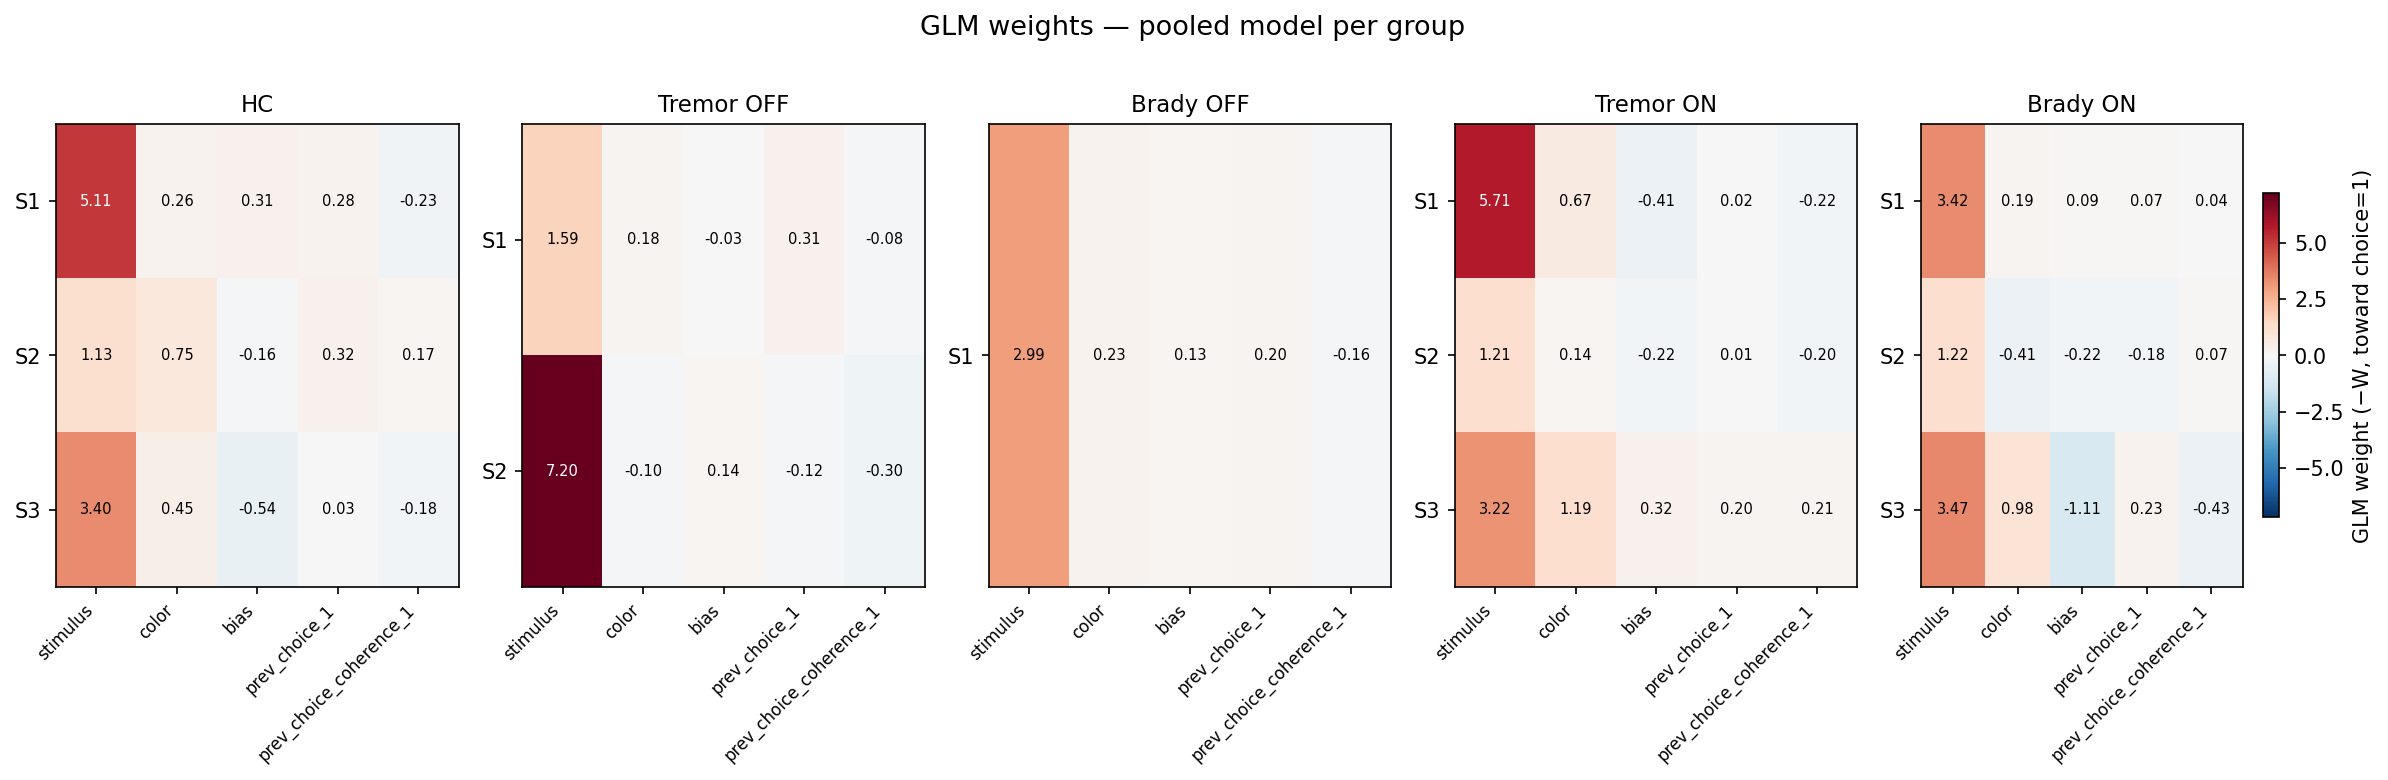

In [7]:
groups_to_plot = [g for g in GROUPS if g in group_data]
n_groups = len(groups_to_plot)

# collect pooled weights for global colour scale
all_ref_w = np.concatenate([group_data[g]['ref_w'] for g in groups_to_plot])
vmax = np.abs(all_ref_w).max()

fig, axes = plt.subplots(1, n_groups,
                          figsize=(3.2 * n_groups, 3 + max(g_data['best_k'] for g_data in group_data.values()) * 0.7),
                          dpi=DPI)
if n_groups == 1:
    axes = [axes]

for ax, g in zip(axes, groups_to_plot):
    gdata  = group_data[g]
    K      = gdata['best_k']
    feats  = gdata['config']['model_features']
    M      = len(feats)
    w      = gdata['ref_w']   # pooled model weights (K, M)

    im = ax.imshow(w, aspect='auto', cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    ax.set_xticks(range(M))
    ax.set_xticklabels(feats, rotation=45, ha='right', fontsize=8)
    ax.set_yticks(range(K))
    ax.set_yticklabels([f'S{k+1}' for k in range(K)], fontsize=10)
    ax.set_title(GROUP_LABELS.get(g, g), fontsize=11)
    for i in range(K):
        for j in range(M):
            ax.text(j, i, f'{w[i, j]:.2f}', ha='center', va='center', fontsize=7,
                    color='white' if abs(w[i, j]) > 0.6 * vmax else 'black')

plt.colorbar(im, ax=axes[-1], label='GLM weight (−W, toward choice=1)', shrink=0.7)
fig.suptitle('GLM weights — pooled model per group', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(fig_dir / 'fig2_weight_heatmaps.pdf', bbox_inches='tight')
plt.show()

## Figure 3 — State Occupancy: 5-Group Bar Plot

Mean ± SEM occupancy per state per group, with individual session dots.

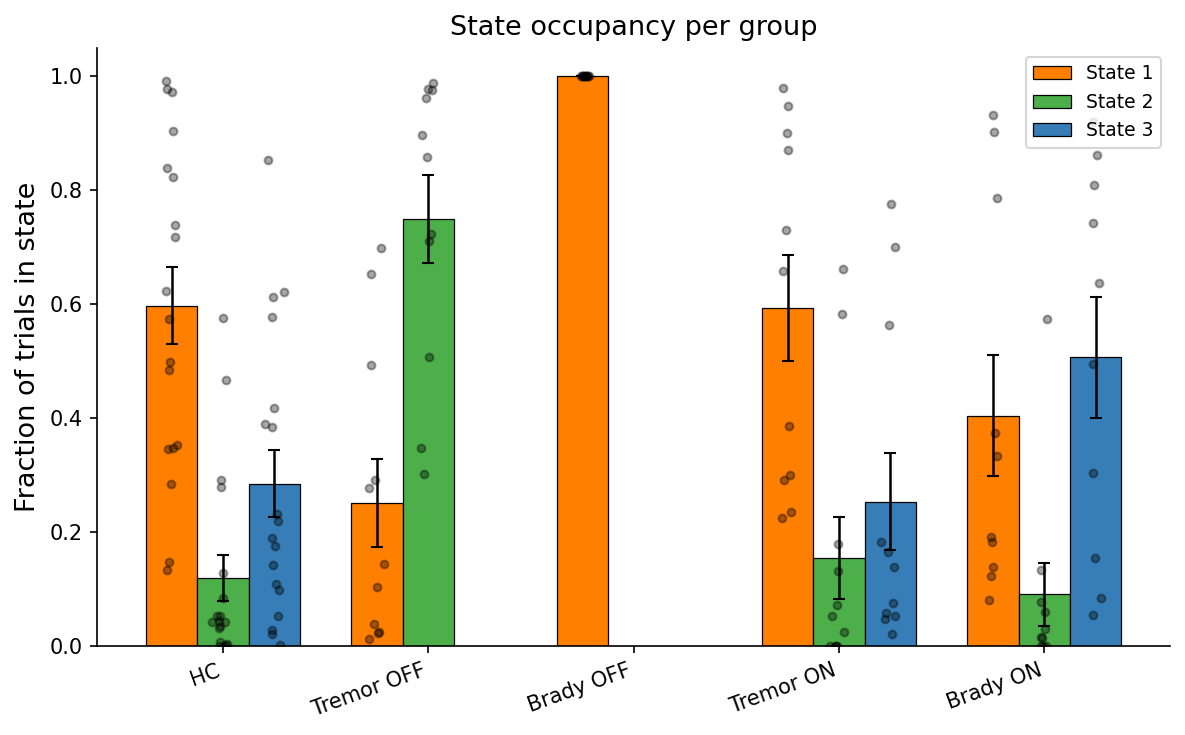

In [8]:
# Use the maximum K across groups for the layout
K_max     = max(group_data[g]['best_k'] for g in groups_to_plot)
x         = np.arange(n_groups)
bar_width = 0.75 / K_max
offsets   = np.linspace(-(K_max - 1) * bar_width / 2,
                         (K_max - 1) * bar_width / 2, K_max)

fig, ax = plt.subplots(figsize=(max(8, 1.6 * n_groups), 5), dpi=DPI)

for k in range(K_max):
    for g_idx, g in enumerate(groups_to_plot):
        gdata = group_data[g]
        if k >= gdata['best_k']:
            continue
        occ  = stacked_occ(gdata)[:, k]
        mean = occ.mean()
        sem  = occ.std(ddof=1) / np.sqrt(len(occ))
        ax.bar(x[g_idx] + offsets[k], mean, width=bar_width, yerr=sem,
               color=STATE_COLORS[k], edgecolor='k', linewidth=0.6,
               capsize=3, error_kw={'elinewidth': 1.2},
               label=f'State {k+1}' if g_idx == 0 else None)
        jit = np.random.normal(0, 0.018, len(occ))
        ax.scatter(x[g_idx] + offsets[k] + jit, occ,
                   color='k', s=14, alpha=0.35, zorder=5)

ax.set_xticks(x)
ax.set_xticklabels([GROUP_LABELS.get(g, g) for g in groups_to_plot],
                   fontsize=10, rotation=20, ha='right')
ax.set_ylabel('Fraction of trials in state', fontsize=13)
ax.set_title('State occupancy per group', fontsize=13)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=9)
despine(ax)
plt.tight_layout()
plt.savefig(fig_dir / 'fig3_state_occupancy.pdf', bbox_inches='tight')
plt.show()

## Figure 4 — State-Specific Psychometric Curves

One row per state, one line per group, solid = color/unequal prior condition, dashed = equal prior.

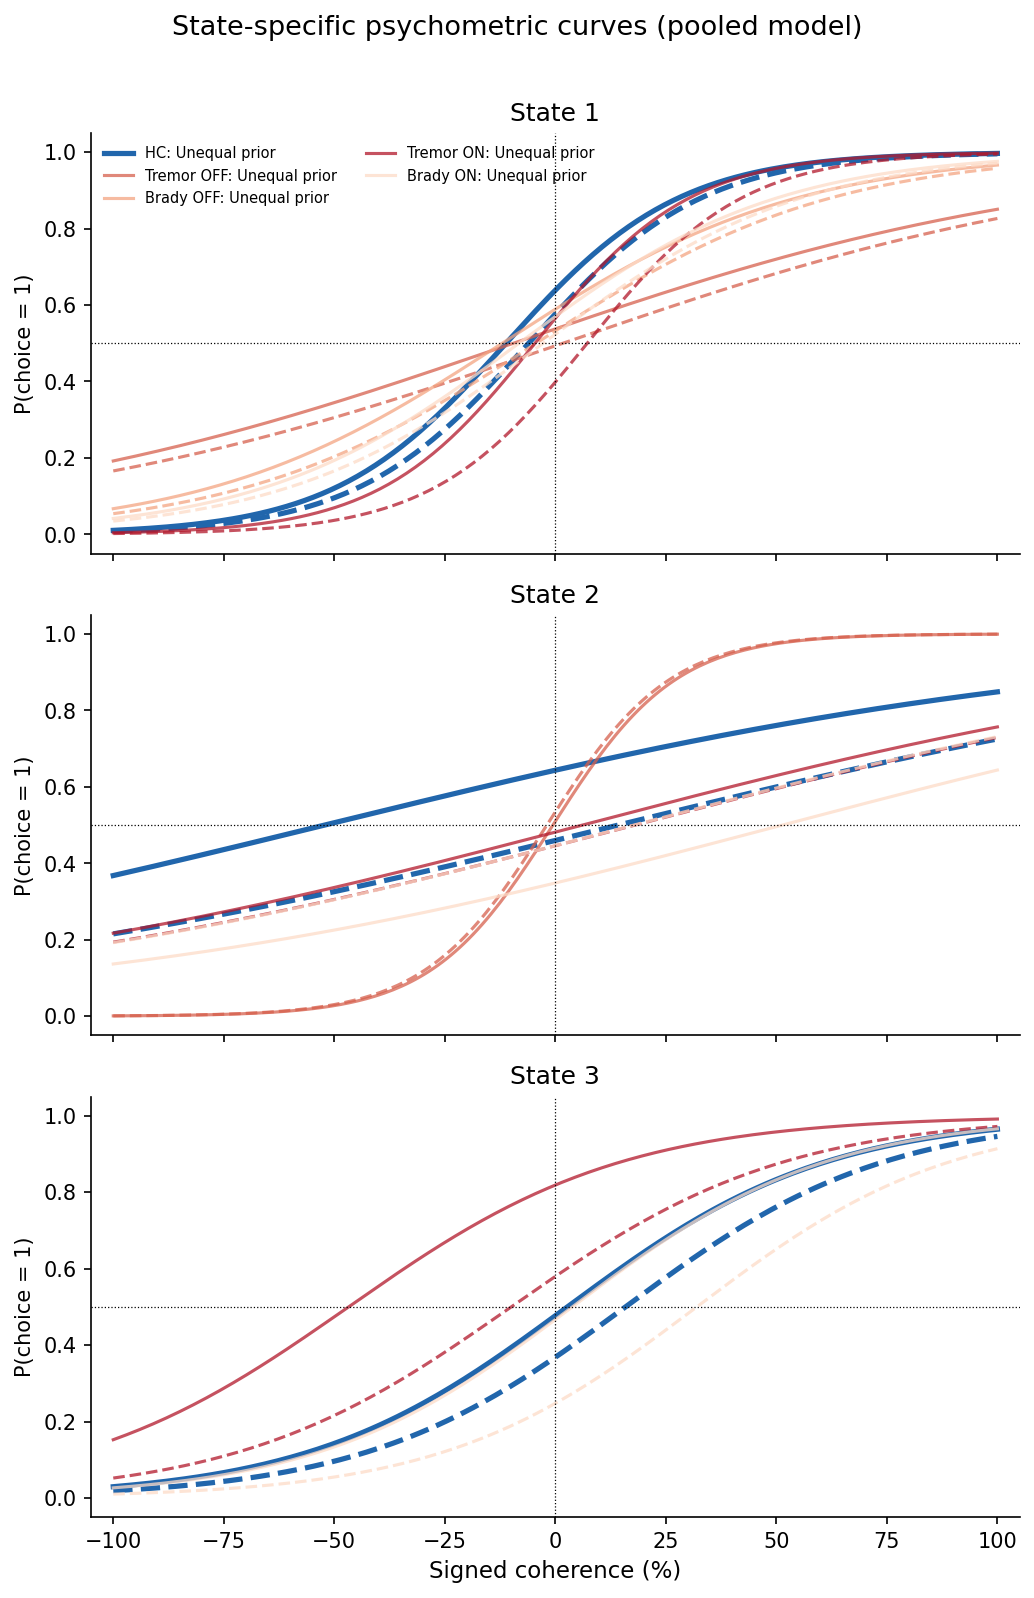

In [9]:
# Use the pooled model weights for clean psychometric curves
x_coh = np.linspace(-1, 1, 200)

# Get feature indices from first group
ref_feats   = group_data[groups_to_plot[0]]['config']['model_features']
stim_idx    = ref_feats.index('stimulus')
bias_idx    = ref_feats.index('bias') if 'bias' in ref_feats else None
color_idx   = ref_feats.index('color') if 'color' in ref_feats else None

fig, axes = plt.subplots(K_max, 1, figsize=(7, 3.5 * K_max), dpi=DPI, sharex=True)
if K_max == 1:
    axes = [axes]

for k in range(K_max):
    ax = axes[k]
    ax.set_title(f'State {k+1}', fontsize=12)

    for g in groups_to_plot:
        gdata = group_data[g]
        if k >= gdata['best_k']:
            continue
        w   = gdata['ref_w'][k]    # (M,) pooled weights
        c   = GROUP_COLORS.get(g, 'gray')
        lw  = 2.5 if g == 'asmHC' else 1.5
        alp = 1.0 if g == 'asmHC' else 0.75

        conditions = [(1.0, '-', 'Unequal prior'), (0.0, '--', 'Equal prior')] if color_idx is not None else [(0.0, '-', '')]
        for color_val, ls, cond_lbl in conditions:
            logit = w[stim_idx] * x_coh
            if color_idx is not None:
                logit = logit + w[color_idx] * color_val
            if bias_idx is not None:
                logit = logit + w[bias_idx]
            lbl = f'{GROUP_LABELS[g]}: {cond_lbl}' if (k == 0 and ls == '-') else None
            ax.plot(x_coh * 100, expit(logit), ls=ls, color=c, lw=lw, alpha=alp, label=lbl)

    ax.axhline(0.5, color='k', lw=0.6, ls=':')
    ax.axvline(0,   color='k', lw=0.6, ls=':')
    ax.set_xlim(-105, 105)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel('P(choice = 1)', fontsize=10)
    despine(ax)

axes[0].legend(fontsize=7, ncol=2, frameon=False)
axes[-1].set_xlabel('Signed coherence (%)', fontsize=11)
fig.suptitle('State-specific psychometric curves (pooled model)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(fig_dir / 'fig4_psychometric_curves.pdf', bbox_inches='tight')
plt.show()

## Figure 5 — Transition Matrices (mean across sessions per group)

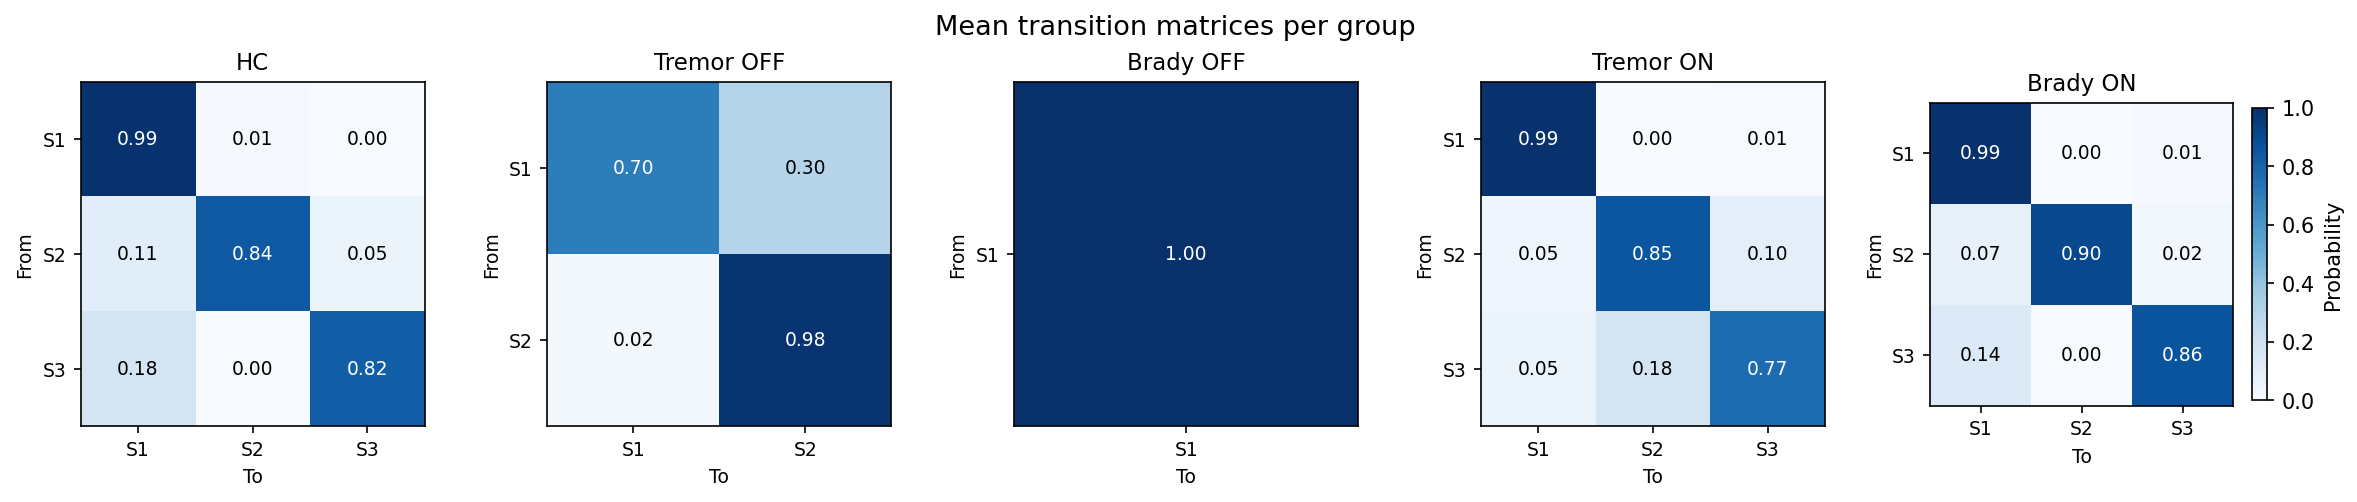

In [10]:
fig, axes = plt.subplots(1, n_groups, figsize=(3.2 * n_groups, 3.2), dpi=DPI)
if n_groups == 1:
    axes = [axes]

for ax, g in zip(axes, groups_to_plot):
    gdata = group_data[g]
    K     = gdata['best_k']
    mats  = np.array([
        np.array(m.transitions.transition_matrix)
        for m in gdata['models'].values()
    ])
    # sessions may have been fitted with a different alignment,
    # but we use the per-session perm to realign the matrices
    aligned_mats = []
    for sid, model in gdata['models'].items():
        T_mat  = np.array(model.transitions.transition_matrix)  # (K, K)
        ref_w  = gdata['ref_w']
        sess_w = gdata['weights'][sid]
        # perm from weights — already stored aligned, so identity
        aligned_mats.append(T_mat)
    mean_T = np.mean(aligned_mats, axis=0)

    im = ax.imshow(mean_T, vmin=0, vmax=1, cmap='Blues')
    ax.set_xticks(range(K))
    ax.set_yticks(range(K))
    ax.set_xticklabels([f'S{i+1}' for i in range(K)], fontsize=9)
    ax.set_yticklabels([f'S{i+1}' for i in range(K)], fontsize=9)
    ax.set_xlabel('To', fontsize=9)
    ax.set_ylabel('From', fontsize=9)
    ax.set_title(GROUP_LABELS.get(g, g), fontsize=11)
    for i in range(K):
        for j in range(K):
            ax.text(j, i, f'{mean_T[i, j]:.2f}', ha='center', va='center', fontsize=9,
                    color='white' if mean_T[i, j] > 0.6 else 'black')

plt.colorbar(im, ax=axes[-1], label='Probability', shrink=0.85)
fig.suptitle('Mean transition matrices per group', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'fig5_transition_matrices.pdf', bbox_inches='tight')
plt.show()

## Figure 6 — Paired Medication Effect (ON vs OFF)

State occupancy connected within subject for Tremor and Bradykinesia subgroups.

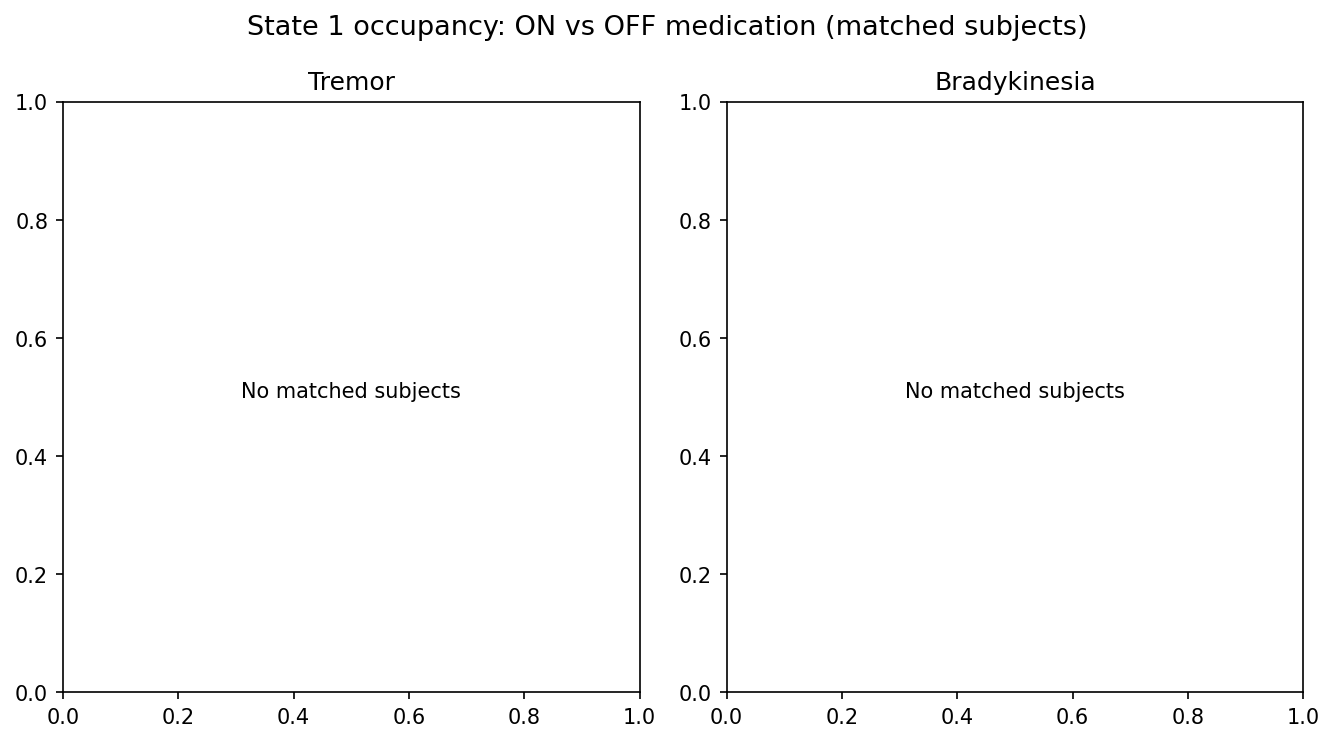

In [11]:
# We compare state-1 occupancy (index 0 after alignment).
# Sessions are matched by session_id prefix (subject ID) between OFF and ON groups.

def extract_subject(session_id):
    """Extract subject identifier from session_id (first two underscore-separated tokens)."""
    parts = str(session_id).split('_')
    return '_'.join(parts[:2]) if len(parts) >= 2 else str(session_id)


valid_pairs = [(lbl, off, on) for lbl, off, on in MED_PAIRS
               if off in group_data and on in group_data]

if valid_pairs:
    fig, axes = plt.subplots(1, len(valid_pairs),
                              figsize=(4.5 * len(valid_pairs), 5), dpi=DPI)
    if len(valid_pairs) == 1:
        axes = [axes]

    for ax, (lbl, off_key, on_key) in zip(axes, valid_pairs):
        off_data  = group_data[off_key]
        on_data   = group_data[on_key]

        # Map subject → mean occupancy (state 0) across sessions
        def subj_occ(gdata, k_state=0):
            subj_map = {}
            for sid in gdata['session_ids']:
                subj = extract_subject(sid)
                occ  = gdata['occupancy'][sid][k_state] if k_state < gdata['best_k'] else np.nan
                subj_map.setdefault(subj, []).append(occ)
            return {s: np.nanmean(v) for s, v in subj_map.items()}

        off_map = subj_occ(off_data)
        on_map  = subj_occ(on_data)
        common  = sorted(set(off_map) & set(on_map))

        if not common:
            ax.text(0.5, 0.5, 'No matched subjects', transform=ax.transAxes, ha='center')
            ax.set_title(lbl)
            continue

        off_v = np.array([off_map[s] for s in common])
        on_v  = np.array([on_map[s]  for s in common])
        n     = len(common)

        for ov, nv in zip(off_v, on_v):
            ax.plot([0, 1], [ov, nv], color='gray', lw=0.8, alpha=0.5)
        ax.scatter([0] * n, off_v, color=GROUP_COLORS.get(off_key, 'gray'),
                   s=50, zorder=5, edgecolors='k', lw=0.5)
        ax.scatter([1] * n, on_v,  color=GROUP_COLORS.get(on_key,  'gray'),
                   s=50, zorder=5, edgecolors='k', lw=0.5)
        for xi, vals, ck in [(0, off_v, off_key), (1, on_v, on_key)]:
            ax.errorbar(xi, vals.mean(), yerr=vals.std(ddof=1) / np.sqrt(n),
                        fmt='o', color=GROUP_COLORS.get(ck, 'gray'), ms=12,
                        capsize=5, capthick=2, elinewidth=2, zorder=10,
                        markeredgecolor='k', markeredgewidth=1)

        if n >= 4:
            _, p = wilcoxon(off_v, on_v, alternative='two-sided')
            sig  = ('***' if p < 0.001 else
                    '**'  if p < 0.01  else
                    '*'   if p < 0.05  else 'n.s.')
            y_max = max(on_v.max(), off_v.max()) + 0.06
            ax.plot([0, 1], [y_max, y_max], 'k', lw=1)
            ax.text(0.5, y_max + 0.01, f'{sig} (p={p:.3f})', ha='center', fontsize=9)

        ax.set_xticks([0, 1])
        ax.set_xticklabels(['OFF', 'ON'], fontsize=12)
        ax.set_ylabel('State 1 occupancy', fontsize=11)
        ax.set_title(lbl, fontsize=13)
        ax.set_ylim(-0.02, 1.1)
        despine(ax)

    fig.suptitle('State 1 occupancy: ON vs OFF medication (matched subjects)', fontsize=13)
    plt.tight_layout()
    plt.savefig(fig_dir / 'fig6_medication_paired.pdf', bbox_inches='tight')
    plt.show()
else:
    print('No valid ON/OFF group pairs found — skipping Fig 6.')

## Figure 7 — Trial-Level State Posteriors (Example Sessions)

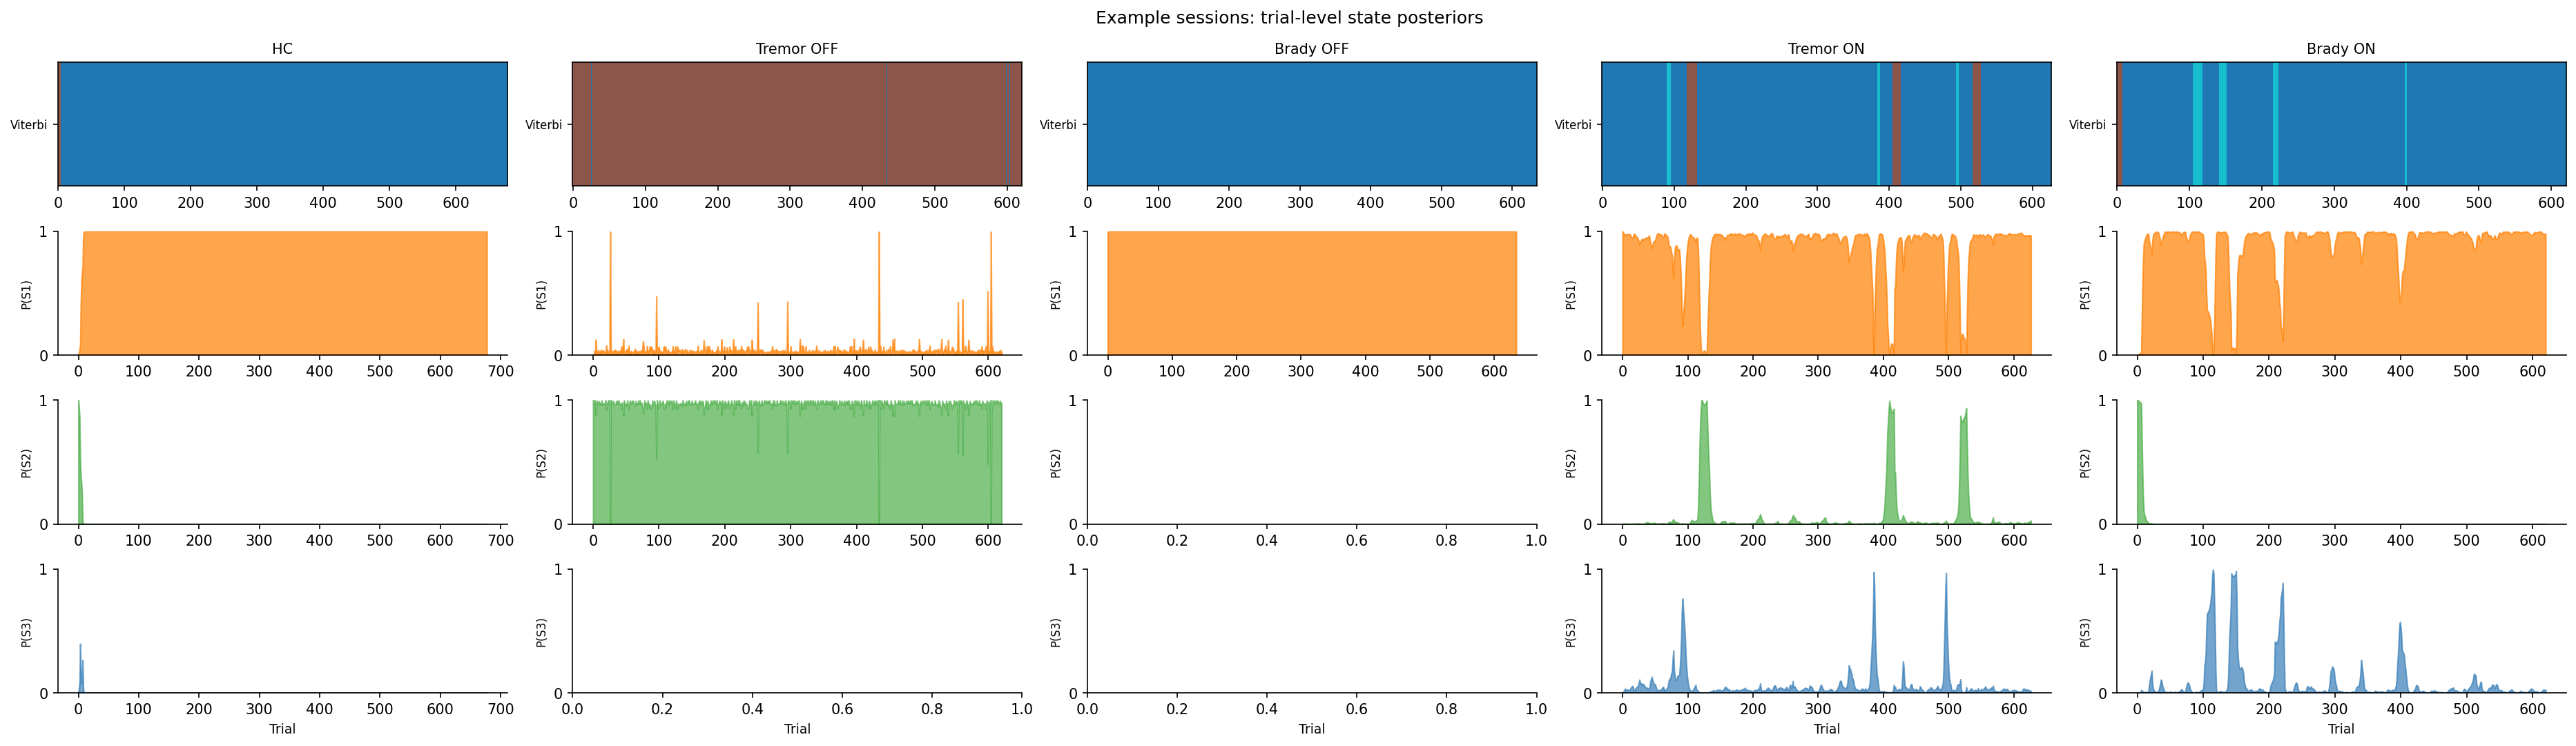

In [12]:
example_groups = [g for g in groups_to_plot if len(group_data[g]['session_ids']) > 0]
n_cols  = len(example_groups)
n_rows  = K_max + 1   # viterbi row + K posterior rows

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(5 * n_cols, 2.5 + n_rows * 1.2),
                          sharex=False, dpi=DPI)
if n_cols == 1:
    axes = axes.reshape(-1, 1)

for col, g in enumerate(example_groups):
    gdata   = group_data[g]
    sid     = gdata['session_ids'][0]
    K       = gdata['best_k']
    post    = gdata['posteriors'][sid]      # (T, K_model)
    vit     = gdata['viterbi'][sid]         # (T_valid,)
    T_valid = len(vit)

    # Viterbi row — pad to K_max colours
    axes[0, col].imshow(vit.reshape(1, -1), aspect='auto',
                        cmap='tab10', vmin=0, vmax=K_max - 1,
                        interpolation='none')
    axes[0, col].set_yticks([0])
    axes[0, col].set_yticklabels(['Viterbi'], fontsize=8)
    axes[0, col].set_title(GROUP_LABELS.get(g, g), fontsize=10)

    # Posterior rows
    df      = gdata['raw']['data'][sid]
    valid   = df['mask'].values.astype(bool)
    post_v  = post[valid]    # (T_valid, K)

    for k in range(K_max):
        ax = axes[k + 1, col]
        if k < K:
            ax.fill_between(range(T_valid), post_v[:, k],
                            color=STATE_COLORS[k], alpha=0.7)
        ax.set_ylim(0, 1)
        ax.set_yticks([0, 1])
        ax.set_ylabel(f'P(S{k+1})', fontsize=8)
        despine(ax)
    axes[-1, col].set_xlabel('Trial', fontsize=9)

fig.suptitle('Example sessions: trial-level state posteriors', fontsize=12)
plt.tight_layout()
plt.savefig(fig_dir / 'fig7_example_posteriors.pdf', bbox_inches='tight')
plt.show()

## Figure 8 — Dwell Time Distributions

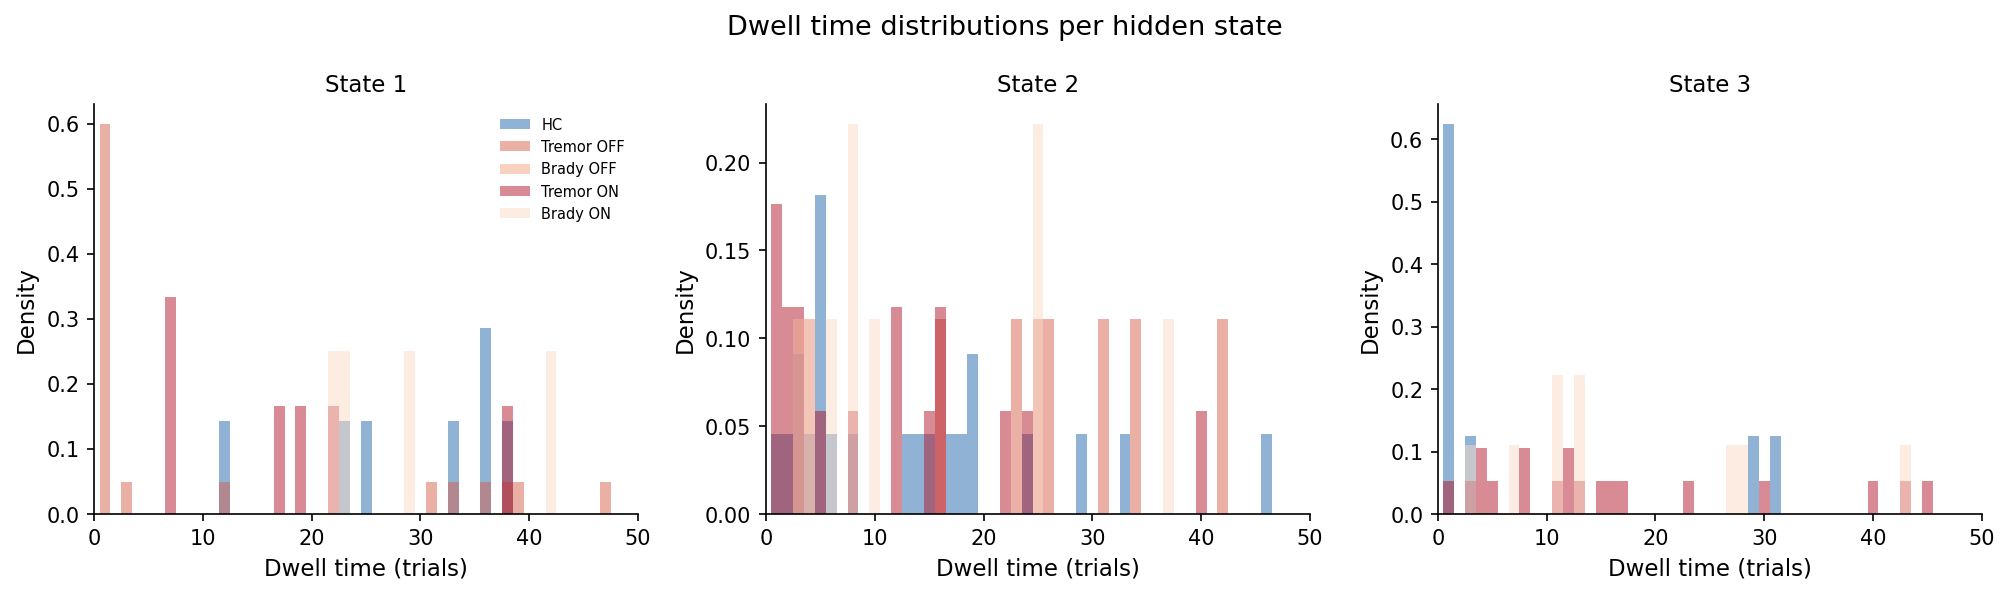

In [13]:
def compute_dwell_times(viterbi_dict, k_state):
    dwells = []
    for vit in viterbi_dict.values():
        count = 0
        for s in vit:
            if s == k_state:
                count += 1
            else:
                if count > 0:
                    dwells.append(count)
                count = 0
        if count > 0:
            dwells.append(count)
    return np.array(dwells)


fig, axes = plt.subplots(1, K_max, figsize=(4.5 * K_max, 4), dpi=DPI)
if K_max == 1:
    axes = [axes]

for k in range(K_max):
    ax = axes[k]
    for g in groups_to_plot:
        gdata = group_data[g]
        if k >= gdata['best_k']:
            continue
        d = compute_dwell_times(gdata['viterbi'], k)
        if len(d) == 0:
            continue
        ax.hist(d, bins=np.arange(0.5, 51.5), density=True, alpha=0.5,
                color=GROUP_COLORS.get(g, 'gray'), label=GROUP_LABELS.get(g, g))
    ax.set_title(f'State {k+1}', fontsize=11)
    ax.set_xlabel('Dwell time (trials)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_xlim(0, 50)
    despine(ax)
    if k == 0:
        ax.legend(fontsize=7, frameon=False)

fig.suptitle('Dwell time distributions per hidden state', fontsize=13)
plt.tight_layout()
plt.savefig(fig_dir / 'fig8_dwell_times.pdf', bbox_inches='tight')
plt.show()

In [14]:
import os
print(f'Figures saved to: {fig_dir}')
for f in sorted(os.listdir(fig_dir)):
    print(f'  {f}')

Figures saved to: /mnt/pd-data/processed/glm_hmm/no_standardization_curr_stim_color_no_prev_coh__global_pooled_cv/figures
  fig1_model_selection.pdf
  fig2_weight_heatmaps.pdf
  fig3_state_occupancy.pdf
  fig4_psychometric_curves.pdf
  fig5_transition_matrices.pdf
  fig6_medication_paired.pdf
  fig7_example_posteriors.pdf
  fig8_dwell_times.pdf
